In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_smc_config
import arviz as az

In [2]:
# samples = np.load(f"../../../../output/age_depth_pymc/samples_{config_str}.npy")
# print(np.shape(samples))
import xarray as xr

posterior = xr.load_dataset("samples.nc")
# samples = iData.posterior['sed_rates'].values
# bias_values = iData.sample_stats['bias_value'].values
# delF = iData.sample_stats['delta_F'].values
# acceptance = iData.sample_stats['acceptance_rate'].values
# energy_values = -iData.sample_stats['lp'].values
posterior_samples = posterior.sed_rates.to_numpy()
print(np.shape(posterior_samples))

# resampled_samples = x_resampled
print(posterior)

(5, 10000, 50)
<xarray.Dataset> Size: 20MB
Dimensions:          (draw: 10000, sed_rates_dim_0: 50, chain: 5)
Coordinates:
  * draw             (draw) int32 40kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
  * sed_rates_dim_0  (sed_rates_dim_0) int32 200B 0 1 2 3 4 5 ... 45 46 47 48 49
  * chain            (chain) int32 20B 0 1 2 3 4
Data variables:
    sed_rates        (chain, draw, sed_rates_dim_0) float64 20MB 5.919 ... 5.124
Attributes:
    created_at:                 2026-03-03T12:47:54.430670+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.28.0+7.g3eef176a


In [3]:
data = get_data()
config = get_smc_config()
colors = plt.cm.viridis(np.linspace(0, 1, len(posterior_samples[:, 0, 0])))

In [4]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

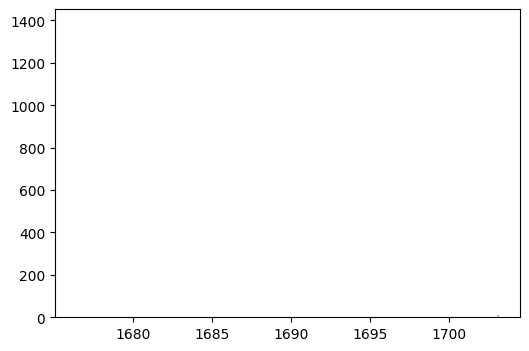

In [5]:
CV_values = data["th"] - data["dc"] * np.sum(posterior_samples[:, :, :int(data["N"]/2)], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(len(CV_values[:, 0])):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

In [6]:
# indices = []
# for i in range(len(data["d18od"])):
#     index = get_index(data["N"], data["cs"], data["d18od"], i)
#     indices.append(index)

# plt.figure()
# plt.plot(data["d18ort"], data["d18or"])
# for i in range(len(posterior_samples[:, 0, 0])):
#     variables = posterior_samples[i,:,:]
#     for j in range(len(variables)):
#         d18O_ages = expected_ages(data["N"], data["dc"], data["cs"], data["th"], len(data["d18od"]), data["d18od"], variables[j,:], indices)
#         plt.plot(d18O_ages, data["d18o"], '*', color = colors[i])

# plt.plot(data["d18ota"], data["d18o"], '*', color = "k")
# plt.show()

In [7]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(posterior_samples)
summary = az.summary(idata, round_to=2)
print(summary)

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    5.48   0.72    4.15     6.17       0.32     0.20      5.25      5.27   
x[1]    4.77   2.94    1.64     9.99       1.31     0.75      5.15      5.24   
x[2]    4.52   2.27    2.66     7.77       1.02     0.26      5.23      5.13   
x[3]    4.59   1.99    2.85     8.42       0.89     0.61      5.23      5.25   
x[4]    3.44   1.50    1.38     5.20       0.67     0.21      5.33      5.26   
x[5]    3.70   1.56    2.26     5.93       0.70     0.18      5.19      5.25   
x[6]    3.62   1.82    2.16     7.16       0.81     0.57      5.24      5.01   
x[7]    5.20   2.01    1.94     7.51       0.89     0.43      5.09      5.02   
x[8]    6.96   4.53    2.44    15.39       2.02     1.31      5.23      5.26   
x[9]    5.42   1.25    3.78     7.55       0.55     0.31      5.19      5.02   
x[10]   9.71   7.16    2.70    23.14       3.20     2.09      5.10      5.35   
x[11]   4.70   3.05    1.47    10.10    

In [8]:
# starting_points = np.load(r"C:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_c14_normal\output\68831df8d5\samples.npy")
# starting_points = np.log(starting_points[:, 100:, :].reshape(-1, starting_points[:, 100:, :].shape[-1]))
# print(starting_points)


In [9]:
# cumulative_sums = np.cumsum(starting_points[:, 100:,:], axis=2) * data["dc"]
# zeros = np.zeros((*starting_points[:,100:,:].shape[:2], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

# model_ages = data["th"] - age_offsets

# mean_model_age = model_ages.mean(axis=(0, 1))

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(starting_points[0,100:,0])
# for i in range(len(starting_points[:, 0, 0])):
#     for j in range(num_samples):
#         ax.plot(
#             data["cs"],
#             model_ages[i, j, :],
#             color=colors[i],
#             alpha=0.3,
#             linewidth=0.1,
#         )
# # for i, c in enumerate(config["cs"]):
# #     ax.axvline(x=c, color='k', linestyle='--')

# ax.set_xlim(0, np.max(data["cs"]))
# plt.plot(data["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.show()

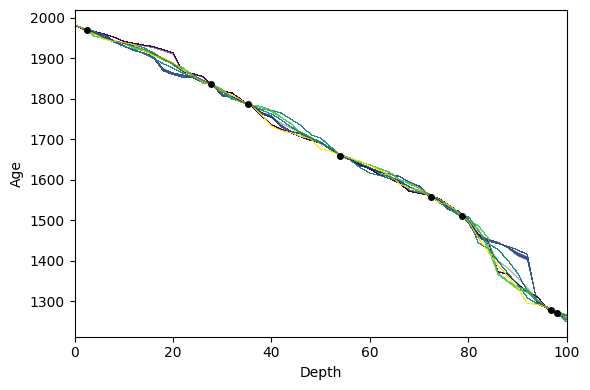

In [10]:
cumulative_sums = np.cumsum(posterior_samples[:, :,:], axis=2) * data["dc"]
zeros = np.zeros((*posterior_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["th"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(posterior_samples[0,:,0])
for i in range(len(posterior_samples[:, 0, 0])):
    for j in range(num_samples):
        ax.plot(
            data["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
# for i, c in enumerate(config["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--')

ax.set_xlim(0, np.max(data["cs"]))
plt.plot(data["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()